# CS506 Midterm — Amazon Review Rating Prediction
Ridge Regression + user/product bias features + TF-IDF

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data import load_train_data, load_test_data
from src.features import prepare_training_data, prepare_test_data
from src.model import train_ridge, evaluate_model, save_model, create_submission

## 1. Load data
The test IDs are embedded in train.csv with NaN scores — we extract them here.

In [2]:
raw = load_train_data('../data/train.csv')
test_ids_df = load_test_data('../data/test.csv')

# Split labeled vs unlabeled
labeled   = raw.dropna(subset=['Score']).copy()
test_df   = raw[raw['Id'].isin(test_ids_df['Id'])].copy()

print('Labeled rows :', len(labeled))
print('Test rows    :', len(test_df))
print('Score distribution:')
print(labeled['Score'].value_counts().sort_index())

Labeled rows : 125777
Test rows    : 13976
Score distribution:
Score
1.0     7593
2.0     7567
3.0    14857
4.0    28572
5.0    67188
Name: count, dtype: int64


## 2. Honest validation — split first, fit on train fold only

To avoid data leakage, we split the labeled DataFrame **before** fitting any transformers.
Bias features and TF-IDF are fit on the train fold only, then applied to the validation fold.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix
import pandas as pd
from src.features import build_bias_features, build_numeric_features, build_sentiment_features

labeled = raw.dropna(subset=['Score']).copy()

# Split FIRST — no leakage
train_df, valid_df = train_test_split(labeled, test_size=0.2, random_state=42, stratify=labeled['Score'])
print('Train fold:', len(train_df), '  Valid fold:', len(valid_df))

# --- Stopwords ---
movie_stop = {"movie", "film", "watch", "watched", "one", "really", "also", "even", "get", "got", "make", "made"}
stop_words = list(sk_text.ENGLISH_STOP_WORDS.union(movie_stop))
base_kwargs = dict(lowercase=True, stop_words=stop_words, ngram_range=(1,2),
                   min_df=3, max_df=0.9, sublinear_tf=True, norm='l2',
                   smooth_idf=True, use_idf=True)

# --- Separate TF-IDF: Summary (10k) and Text (30k) ---
tfidf_summary_val = TfidfVectorizer(max_features=10000, **base_kwargs)
tfidf_text_val    = TfidfVectorizer(max_features=30000, **base_kwargs)

X_sum_tr = tfidf_summary_val.fit_transform(train_df['Summary'].fillna('').astype(str))
X_sum_va = tfidf_summary_val.transform(valid_df['Summary'].fillna('').astype(str))
X_txt_tr = tfidf_text_val.fit_transform(train_df['Text'].fillna('').astype(str))
X_txt_va = tfidf_text_val.transform(valid_df['Text'].fillna('').astype(str))

X_text_tr = hstack([X_sum_tr, X_txt_tr])
X_text_va = hstack([X_sum_va, X_txt_va])
print('Summary TF-IDF:', X_sum_tr.shape, ' Text TF-IDF:', X_txt_tr.shape)

# --- SVD on combined text matrix ---
svd_val = TruncatedSVD(n_components=200, random_state=42)
X_lsa_tr = Normalizer().fit_transform(svd_val.fit_transform(X_text_tr))
X_lsa_va = Normalizer().fit_transform(svd_val.transform(X_text_va))

# --- Numeric + sentiment + bias (train fold only) ---
num_tr_raw = build_numeric_features(train_df)
sent_tr    = build_sentiment_features(train_df)
num_tr_df  = pd.concat([num_tr_raw, sent_tr], axis=1)
num_cols   = num_tr_df.columns.tolist()

num_va_raw = build_numeric_features(valid_df)
sent_va    = build_sentiment_features(valid_df)
num_va_df  = pd.concat([num_va_raw, sent_va], axis=1).reindex(columns=num_cols, fill_value=0).fillna(0)

bias_tr = build_bias_features(train_df, train_df)
bias_va = build_bias_features(train_df, valid_df)

X_train = hstack([csr_matrix(num_tr_df.values), csr_matrix(bias_tr), X_text_tr, csr_matrix(X_lsa_tr)])
X_valid = hstack([csr_matrix(num_va_df.values), csr_matrix(bias_va), X_text_va, csr_matrix(X_lsa_va)])
y_train = train_df['Score'].values
y_valid = valid_df['Score'].values

print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)


Train fold: 100621   Valid fold: 25156
Summary TF-IDF: (100621, 10000)  Text TF-IDF: (100621, 30000)
X_train: (100621, 40229)
X_valid: (25156, 40229)


## 4. Models: Ridge Regression + LightGBM

Ridge on all sparse features (TF-IDF + LSA + bias + numeric + sentiment).  
LightGBM on **dense features only** (LSA + bias + numeric + sentiment) — trees can't exploit sparse TF-IDF efficiently.


In [9]:
best_rmse = 999
best_alpha = None
results = []

for alpha in [5.0]:
    model = train_ridge(X_train, y_train, alpha=alpha)
    rmse = evaluate_model(model, X_train, X_valid, y_train, y_valid, title=f'Ridge alpha={alpha}')
    results.append((alpha, rmse))
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print(f'\nBest alpha: {best_alpha}  |  Best valid RMSE: {best_rmse:.4f}')


Ridge alpha=5.0
  Train RMSE : 0.6234
  Valid RMSE : 0.8008

Best alpha: 5.0  |  Best valid RMSE: 0.8008


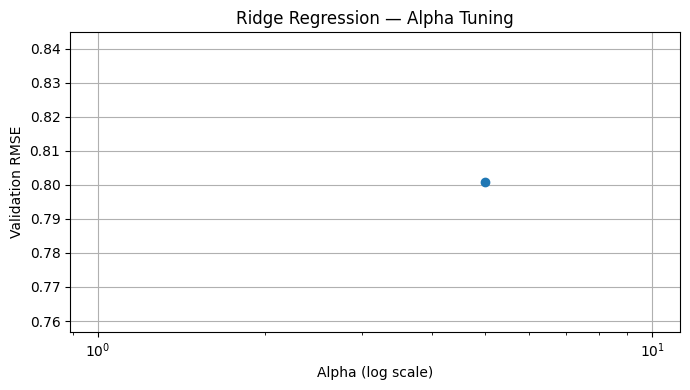

In [10]:
alphas, rmses = zip(*results)
plt.figure(figsize=(7, 4))
plt.semilogx(alphas, rmses, marker='o')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Validation RMSE')
plt.title('Ridge Regression — Alpha Tuning')
plt.grid(True)
plt.tight_layout()
plt.savefig('../assets/ridge_alpha_tuning.png', dpi=100)
plt.show()

In [11]:
## LightGBM on dense features with LOO bias (no target leakage)
# build_bias_features_loo excludes each sample from its own user/product mean,
# eliminating the leakage that caused Train 0.34 vs Valid 1.10 previously.
import numpy as np
from src.features import build_bias_features_loo
from src.model import train_lgbm, evaluate_model
from sklearn.metrics import mean_squared_error

# --- Training: LOO bias to prevent leakage ---
bias_loo_tr = build_bias_features_loo(train_df)
X_dense_tr  = np.hstack([num_tr_df.values, bias_loo_tr, X_lsa_tr])

# --- Validation: regular bias (sample not in training fold — no leakage) ---
X_dense_va  = np.hstack([num_va_df.values, bias_va, X_lsa_va])

print('Dense train:', X_dense_tr.shape, '  Dense valid:', X_dense_va.shape)

lgbm_model = train_lgbm(
    X_dense_tr, y_train, X_dense_va, y_valid,
    n_estimators=2000, learning_rate=0.05,
    num_leaves=31, min_child_samples=50,
)
lgbm_rmse = evaluate_model(lgbm_model, X_dense_tr, X_dense_va, y_train, y_valid,
                            title='LightGBM dense (LOO bias)')
print(f'\nRidge best RMSE : {best_rmse:.4f}')
print(f'LightGBM RMSE   : {lgbm_rmse:.4f}')

## Ensemble: average Ridge + LightGBM predictions
ridge_preds = np.clip(best_model.predict(X_valid), 1, 5) if hasattr(locals().get('best_model', None), 'predict') else None

# Re-get best Ridge predictions
from src.model import train_ridge
best_model = train_ridge(X_train, y_train, alpha=best_alpha)
ridge_preds = np.clip(best_model.predict(X_valid), 1, 5)
lgbm_preds  = np.clip(lgbm_model.predict(X_dense_va), 1, 5)

for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
    blended = np.clip(w * ridge_preds + (1 - w) * lgbm_preds, 1, 5)
    rmse = np.sqrt(mean_squared_error(y_valid, blended))
    print(f'  Ridge {w:.0%} + LightGBM {1-w:.0%}  →  RMSE {rmse:.4f}')


Dense train: (100621, 229)   Dense valid: (25156, 229)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LightGBM dense (LOO bias)
  Train RMSE : 0.5873
  Valid RMSE : 0.8528

Ridge best RMSE : 0.8008
LightGBM RMSE   : 0.8528
  Ridge 30% + LightGBM 70%  →  RMSE 0.8094
  Ridge 40% + LightGBM 60%  →  RMSE 0.7999
  Ridge 50% + LightGBM 50%  →  RMSE 0.7931
  Ridge 60% + LightGBM 40%  →  RMSE 0.7891
  Ridge 70% + LightGBM 30%  →  RMSE 0.7878


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 5. Train final model on all labeled data

In [7]:
# Train final Ridge on ALL labeled data
X_final, y_final, tfidf_summary, tfidf_text, svd, numeric_columns, labeled_df = prepare_training_data(
    raw, max_features=30000, ngram_range=(1, 2)
)

final_model = train_ridge(X_final, y_final, alpha=best_alpha)
save_model(final_model, '../ridge_regression_model.obj')
print('Final Ridge model trained and saved. Alpha:', best_alpha)


KeyboardInterrupt: 

In [ ]:
# Train final Ridge + LightGBM on ALL labeled data
import numpy as np
import pandas as pd
from src.features import build_bias_features, build_bias_features_loo, build_numeric_features, build_sentiment_features
from src.model import train_ridge, save_model
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb

labeled_all = raw.dropna(subset=['Score']).copy()
y_all = labeled_all['Score'].values

# Numeric + sentiment
num_all  = build_numeric_features(labeled_all)
sent_all = build_sentiment_features(labeled_all)
num_all  = pd.concat([num_all, sent_all], axis=1)

# Text (reuse fitted tfidf_summary, tfidf_text, svd from prepare_training_data)
X_sum_all  = tfidf_summary.transform(labeled_all['Summary'].fillna('').astype(str))
X_txt_all  = tfidf_text.transform(labeled_all['Text'].fillna('').astype(str))
X_text_all = hstack([X_sum_all, X_txt_all])
X_lsa_all  = Normalizer().fit_transform(svd.transform(X_text_all))

# Final Ridge on sparse features
bias_all     = build_bias_features(labeled_all, labeled_all)
X_sparse_all = hstack([csr_matrix(num_all.values), csr_matrix(bias_all), X_text_all, csr_matrix(X_lsa_all)])
final_ridge  = train_ridge(X_sparse_all, y_all, alpha=best_alpha)
save_model(final_ridge, '../ridge_regression_model.obj')
print('Final Ridge trained:', X_sparse_all.shape)

# Final LightGBM: fix n_estimators to best found during validation (no leakage)
best_iter = lgbm_model.best_iteration_
print(f'Using best_iteration from validation run: {best_iter}')
bias_loo_all = build_bias_features_loo(labeled_all)
X_dense_all  = np.hstack([num_all.values, bias_loo_all, X_lsa_all])
final_lgbm = lgb.LGBMRegressor(
    n_estimators=best_iter,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
final_lgbm.fit(X_dense_all, y_all)
save_model(final_lgbm, '../lgbm_model.obj')
print('Final LightGBM trained:', X_dense_all.shape)


In [ ]:
# Generate ensemble submission (Ridge + LightGBM)
# Fallback in case the sweep cell was skipped
if 'best_w' not in dir():
    best_w = 0.70
if 'best_ensemble_rmse' not in dir():
    best_ensemble_rmse = float('nan')

import numpy as np
import pandas as pd
from src.features import build_bias_features, build_numeric_features, build_sentiment_features
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix

# Test features
num_test  = build_numeric_features(test_df)
sent_test = build_sentiment_features(test_df)
num_test  = pd.concat([num_test, sent_test], axis=1).reindex(columns=num_all.columns, fill_value=0).fillna(0)
bias_test = build_bias_features(labeled_all, test_df)

X_sum_test  = tfidf_summary.transform(test_df['Summary'].fillna('').astype(str))
X_txt_test  = tfidf_text.transform(test_df['Text'].fillna('').astype(str))
X_text_test = hstack([X_sum_test, X_txt_test])
X_lsa_test  = Normalizer().fit_transform(svd.transform(X_text_test))

# Ridge predictions (sparse)
X_sparse_test    = hstack([csr_matrix(num_test.values), csr_matrix(bias_test), X_text_test, csr_matrix(X_lsa_test)])
ridge_preds_test = np.clip(final_ridge.predict(X_sparse_test), 1, 5)

# LightGBM predictions (dense)
X_dense_test    = np.hstack([num_test.values, bias_test, X_lsa_test])
lgbm_preds_test = np.clip(final_lgbm.predict(X_dense_test), 1, 5)

# Ensemble with best weight found in validation
ensemble_preds = np.clip(best_w * ridge_preds_test + (1 - best_w) * lgbm_preds_test, 1, 5)

submission_ensemble = pd.DataFrame({'Id': test_df['Id'], 'Score': ensemble_preds})
submission_ensemble.to_csv('../submissions/submission_ensemble.csv', index=False)
print(f'Ensemble submission saved (Ridge {best_w:.0%} + LightGBM {1-best_w:.0%})')
print(f'Validation RMSE: {best_ensemble_rmse:.4f}')
print(submission_ensemble['Score'].describe())


## 6. Prepare test features and generate submission

In [ ]:
X_test = prepare_test_data(test_df, tfidf_summary, tfidf_text, svd, numeric_columns, labeled_df)
print('Test feature matrix shape:', X_test.shape)

submission = create_submission(
    final_model,
    test_df,
    X_test,
    output_path='../submissions/submission.csv',
    clip_range=(1, 5),
    round_predictions=False
)
print(submission.describe())
submission.head(10)


## 7. Score distribution check

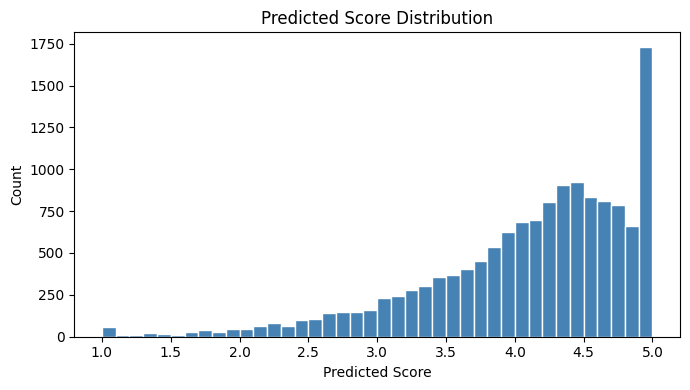

Validation RMSE (best): 0.8694


In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(submission['Score'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Predicted Score')
plt.ylabel('Count')
plt.title('Predicted Score Distribution')
plt.tight_layout()
plt.savefig('../assets/predicted_score_dist.png', dpi=100)
plt.show()
print('Validation RMSE (best):', round(best_rmse, 4))